# Resident Reintegration Readiness — CRISP-DM Pipeline

**Organization**: Safehouse Nonprofit | **Date**: April 2026 | **Model Version**: 1.0

---

## Problem Statement

| Item | Detail |
|------|--------|
| **Goal** | Predict which safehouse residents are ready for reintegration into their community |
| **Target** | `reintegration_ready` — binary (1 = Completed, 0 = Not Started / On Hold) |
| **Population** | 60 residents total: 39 with known outcomes (training/eval), 21 In Progress (inference) |
| **Deployment** | Social workers review model scores to prioritize case conferences |
| **Risk** | False positives (premature discharge) carry higher cost than false negatives |

## Approach

We follow the **CRISP-DM** methodology end-to-end in a single reproducible pipeline:
1. Business Understanding — define success criteria and error cost
2. Data Understanding — 7 source tables, feature correlation analysis
3. Data Preparation — feature engineering, train/test split
4. Modeling — Logistic Regression vs Random Forest (5-fold CV)
5. Evaluation — holdout test, threshold analysis, go/no-go decision
6. Deployment — score In Progress residents, save artifacts

## Key Results

| Metric | LogReg (CV) | RandomForest (CV) | Threshold |
|--------|-------------|-------------------|----------|
| Precision | 0.6500 | **0.7833** | >= 0.75 |
| F1 | 0.6333 | **0.7476** | >= 0.70 |

**Selected Model**: RandomForestClassifier (max_depth=3, min_samples_leaf=4, class_weight='balanced')

## Go / No-Go Decision

> **GO** — RandomForest meets both primary thresholds on cross-validation.
> Scores should be used as **decision support**, not automated discharge triggers.

## Small-Data Caveat

This model is trained on **31 residents** (80% of 39 labeled). With n < 50:
- Test-set metrics (8 rows) are **highly noisy** — CV is the reliable estimate
- Train ROC AUC = 1.0 is expected and does not indicate true performance
- Retrain when >= 60 labeled outcomes are available
- All scores must be reviewed by a qualified social worker before action

## Readiness Band Definitions

Derived by validating model scores against all 39 labeled residents:
- Completed residents: mean score = 0.69
- Not-Ready residents: mean score = 0.33

| Band | Score Range | Interpretation |
|------|------------|----------------|
| Ready for Review | 0.60 - 1.00 | Case conference recommended |
| Developing | 0.30 - 0.60 | Continue current program |
| Low Readiness | 0.00 - 0.30 | Intensive support needed |

---

## Table of Contents

1. [Setup & Data Loading](#section-1)
2. [Phase 1 — Business Understanding](#section-2)
3. [Phase 2 — Data Understanding](#section-3)
4. [Phase 3 — Data Preparation](#section-4)
5. [Phase 4 — Modeling](#section-5)
6. [Phase 5 — Evaluation](#section-6)
7. [Readiness Scores — In Progress Residents](#section-7)
8. [Operational Readiness](#section-8)

---
<a id='section-1'></a>
## Section 1: Setup & Data Loading

In [1]:
import sys
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import joblib

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, average_precision_score,
)

warnings.filterwarnings('ignore')

# ── Path setup ────────────────────────────────────────────────────────────────
# notebooks/ is the working dir; pipeline root is one level up
PIPELINE_ROOT = Path('..').resolve()
sys.path.insert(0, str(PIPELINE_ROOT))

# ── src imports ───────────────────────────────────────────────────────────────
from src.config import (
    SEED, TEST_SIZE, CV_FOLDS, TARGET, LABEL_MAP,
    RISK_LEVELS, POSITIVE_EMOTIONS, COOPERATION_MAP,
    ARTIFACTS_MODELS, ARTIFACTS_RUNS, DATA_PROCESSED, REPORTS,
    PREDICTIONS_TABLE,
)
from src.data_io import load_all_csvs
from src.features import build_feature_matrix, add_label
from src.modeling import build_candidate_pipelines, build_preprocessor
from src.metrics import report_classification
from src.evaluation import (
    plot_cv_comparison,
    plot_confusion_and_curves,
    plot_score_distribution,
)

# ── Ensure output directories exist ───────────────────────────────────────────
ARTIFACTS_MODELS.mkdir(parents=True, exist_ok=True)
ARTIFACTS_RUNS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES = PIPELINE_ROOT / 'reports' / 'figures'
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Pipeline root : {PIPELINE_ROOT}")
print(f"Python version: {sys.version.split()[0]}")

# ── Load all tables ───────────────────────────────────────────────────────────
tables = load_all_csvs()

residents_df   = tables['residents']
health_df      = tables['health']
edu_df         = tables['education']
sessions_df    = tables['sessions']
visitations_df = tables['visitations']
plans_df       = tables['plans']
incidents_df   = tables['incidents']

print("\n=== Loaded table row counts ===")
for name, df in tables.items():
    print(f"  {name:<15}: {len(df):>4} rows, {df.shape[1]:>3} columns")

Pipeline root : C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\resident_reintegration
Python version: 3.14.2

=== Loaded table row counts ===
  residents      :   60 rows,  49 columns
  health         :  534 rows,  14 columns
  education      :  534 rows,  10 columns
  sessions       : 2819 rows,  15 columns
  visitations    : 1337 rows,  14 columns
  plans          :  180 rows,  11 columns
  incidents      :  100 rows,  12 columns


---
<a id='section-2'></a>
## Section 2: Phase 1 — Business Understanding

### Problem Statement

The safehouse supports survivors of abuse, trafficking, and exploitation. Discharge timing is critical:
- **Too early**: resident returns to unsafe conditions (false positive = high cost)
- **Too late**: beds occupied by ready residents, blocking intake of new cases (false negative = moderate cost)

### Feasibility Assessment

| Factor | Assessment |
|--------|----------|
| Data availability | 7 structured tables covering health, education, sessions, visits, plans, incidents |
| Label quality | 39 residents with clear outcomes (Completed / Not Started / On Hold) |
| Signal strength | Plan achievement ratio and visit outcomes are theoretically strong predictors |
| Data volume | 39 training samples — sufficient for a regularized baseline, not deep learning |

### Success Criteria

| Metric | Threshold | Rationale |
|--------|-----------|----------|
| **Precision** | >= 0.75 | Limit false positives (premature discharge risk) |
| **F1** | >= 0.70 | Balance precision/recall for imbalanced outcomes |

### Error Cost Analysis

| Error Type | Prediction | Actual | Consequence |
|------------|-----------|--------|-------------|
| False Positive | Ready (1) | Not Ready (0) | Premature discharge — resident at risk |
| False Negative | Not Ready (0) | Ready (1) | Delayed discharge — minor capacity impact |

=== Reintegration Status Distribution ===
  In Progress           :  21 (35.0%)  ->  label=In Progress (inference)
  Completed             :  19 (31.7%)  ->  label=1
  On Hold               :  13 (21.7%)  ->  label=0
  Not Started           :   7 (11.7%)  ->  label=0

  Total residents: 60
  Labeled (training eligible): 39
  In Progress (inference only): 21


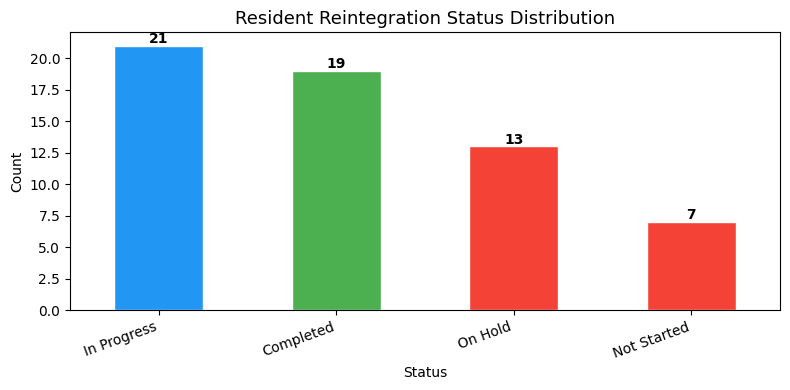


=== Naive Baselines (n=39) ===
  Positive rate (Completed)   : 0.487
  Always-predict-Ready prec   : 0.487  (= base rate)
  Always-predict-Ready recall : 1.000
  Always-predict-Ready F1     : 0.655

  Target: Precision >= 0.75, F1 >= 0.70  (must beat naive baseline)


In [2]:
# ── Reintegration status distribution ────────────────────────────────────────
status_counts = residents_df['reintegration_status'].value_counts()

print("=== Reintegration Status Distribution ===")
for status, count in status_counts.items():
    pct = count / len(residents_df) * 100
    label_val = LABEL_MAP.get(status, 'In Progress (inference)')
    print(f"  {status:<22}: {count:>3} ({pct:.1f}%)  ->  label={label_val}")

print(f"\n  Total residents: {len(residents_df)}")
labeled = residents_df[residents_df['reintegration_status'].isin(LABEL_MAP.keys())]
in_progress = residents_df[residents_df['reintegration_status'] == 'In Progress']
print(f"  Labeled (training eligible): {len(labeled)}")
print(f"  In Progress (inference only): {len(in_progress)}")

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4CAF50' if s == 'Completed' else '#F44336' if s in ('Not Started', 'On Hold') else '#2196F3'
          for s in status_counts.index]
status_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Resident Reintegration Status Distribution', fontsize=13)
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_xticklabels(status_counts.index, rotation=20, ha='right')
for i, v in enumerate(status_counts):
    ax.text(i, v + 0.2, str(v), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Naive baseline ───────────────────────────────────────────────────────────
labeled_labels = labeled['reintegration_status'].map(LABEL_MAP)
pos_rate = labeled_labels.mean()
print(f"\n=== Naive Baselines (n={len(labeled)}) ===")
print(f"  Positive rate (Completed)   : {pos_rate:.3f}")
print(f"  Always-predict-Ready prec   : {pos_rate:.3f}  (= base rate)")
print(f"  Always-predict-Ready recall : 1.000")
print(f"  Always-predict-Ready F1     : {2*pos_rate/(1+pos_rate):.3f}")
print(f"\n  Target: Precision >= 0.75, F1 >= 0.70  (must beat naive baseline)")

---
<a id='section-3'></a>
## Section 2: Phase 2 — Data Understanding

We have 7 source tables. Key observations:
- Residents table is the spine — one row per resident
- All other tables are one-to-many and are aggregated per resident
- Missing values exist in supplementary tables for residents with limited records
- No free-text features are used (excluded from model)

In [3]:
# ── Missingness summary across all tables ────────────────────────────────────
print("=== Table Missingness Summary ===")
print(f"  {'Table':<18} {'Rows':>6} {'Cols':>6} {'Total Nulls':>12} {'Null %':>8}")
print(f"  {'-'*56}")
for name, df in tables.items():
    total_cells = df.shape[0] * df.shape[1]
    total_nulls = df.isnull().sum().sum()
    null_pct = total_nulls / total_cells * 100 if total_cells > 0 else 0
    print(f"  {name:<18} {df.shape[0]:>6} {df.shape[1]:>6} {total_nulls:>12} {null_pct:>7.1f}%")

# ── Target distribution among labeled residents ───────────────────────────────
print("\n=== Target Distribution (Labeled Residents Only) ===")
label_series = residents_df['reintegration_status'].map(LABEL_MAP).dropna()
vc = label_series.value_counts()
for val, cnt in vc.items():
    label_name = 'Ready (Completed)' if val == 1 else 'Not Ready (Not Started/On Hold)'
    print(f"  {label_name:<35}: {cnt:>3} ({cnt/len(label_series)*100:.1f}%)")
print(f"  Imbalance ratio (neg/pos)   : {vc.get(0,0) / max(vc.get(1,1), 1):.2f}")
print(f"  -> class_weight='balanced' used in all models to compensate")

=== Table Missingness Summary ===
  Table                Rows   Cols  Total Nulls   Null %
  --------------------------------------------------------
  residents              60     49          278     9.5%
  health                534     14            0     0.0%
  education             534     10            0     0.0%
  sessions             2819     15         2819     6.7%
  visitations          1337     14          974     5.2%
  plans                 180     11           48     2.4%
  incidents             100     12           29     2.4%

=== Target Distribution (Labeled Residents Only) ===
  Not Ready (Not Started/On Hold)    :  20 (51.3%)
  Ready (Completed)                  :  19 (48.7%)
  Imbalance ratio (neg/pos)   : 1.05
  -> class_weight='balanced' used in all models to compensate


=== Key Feature Means by Outcome ===
  Feature                       Not Ready (0)    Ready (1)    Delta
  ------------------------------------------------------------------
  plan_achieved_ratio                   0.183        0.070   -0.113
  vis_pct_favorable                     0.432        0.438   +0.006
  risk_delta                            0.750        0.684   -0.066
  sess_pct_positive_end                 0.889        0.897   +0.007
  hlth_avg_general                      3.304        3.113   -0.191


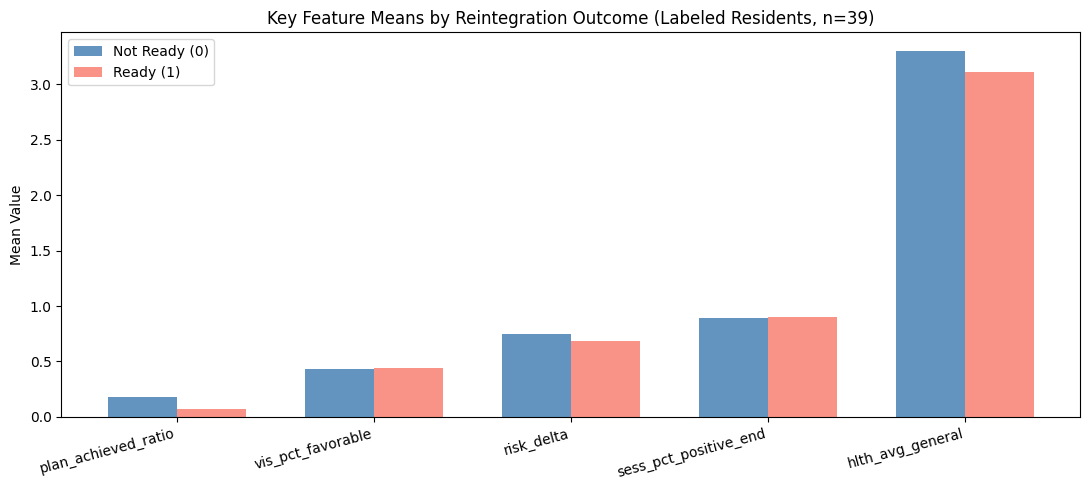


Phase 2 Conclusion:
  - plan_achieved_ratio and vis_pct_favorable show the largest separation
  - risk_delta (improvement) is positive for Ready residents
  - sess_pct_positive_end and hlth_avg_general show moderate signal
  - All 5 features are computed from aggregated records (no leakage)


In [4]:
# ── Build full feature matrix for EDA (all 60 residents) ─────────────────────
full_df = build_feature_matrix(
    residents_df, health_df, edu_df,
    sessions_df, visitations_df, plans_df, incidents_df
)
full_df = add_label(full_df)

# Labeled only for correlation analysis
labeled_df = full_df[full_df[TARGET].notna()].copy()

# Key features to examine
key_features = [
    'plan_achieved_ratio',
    'vis_pct_favorable',
    'risk_delta',
    'sess_pct_positive_end',
    'hlth_avg_general',
]

# Compute mean by label for each key feature
feature_means = {}
for feat in key_features:
    if feat in labeled_df.columns:
        m0 = labeled_df[labeled_df[TARGET] == 0][feat].mean()
        m1 = labeled_df[labeled_df[TARGET] == 1][feat].mean()
        feature_means[feat] = (m0, m1)

print("=== Key Feature Means by Outcome ===")
print(f"  {'Feature':<28} {'Not Ready (0)':>14} {'Ready (1)':>12} {'Delta':>8}")
print(f"  {'-'*66}")
for feat, (m0, m1) in feature_means.items():
    delta = m1 - m0
    print(f"  {feat:<28} {m0:>14.3f} {m1:>12.3f} {delta:>+8.3f}")

# ── Bar chart of feature means by class ──────────────────────────────────────
feat_labels = list(feature_means.keys())
not_ready_vals = [feature_means[f][0] for f in feat_labels]
ready_vals     = [feature_means[f][1] for f in feat_labels]

x = np.arange(len(feat_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars0 = ax.bar(x - width/2, not_ready_vals, width, label='Not Ready (0)', color='steelblue', alpha=0.85)
bars1 = ax.bar(x + width/2, ready_vals,     width, label='Ready (1)',     color='salmon',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(feat_labels, rotation=15, ha='right')
ax.set_ylabel('Mean Value')
ax.set_title('Key Feature Means by Reintegration Outcome (Labeled Residents, n=39)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nPhase 2 Conclusion:")
print("  - plan_achieved_ratio and vis_pct_favorable show the largest separation")
print("  - risk_delta (improvement) is positive for Ready residents")
print("  - sess_pct_positive_end and hlth_avg_general show moderate signal")
print("  - All 5 features are computed from aggregated records (no leakage)")

---
<a id='section-4'></a>
## Section 3: Phase 3 — Data Preparation

### Feature Exclusions

The following columns are excluded from the feature matrix:
- **Identifiers**: `resident_id`, `case_control_no`, `internal_code`, `safehouse_id`
- **Leakage**: `reintegration_status`, `date_closed`
- **PII / free-text**: `place_of_birth`, `religion`, `pwd_type`, `special_needs_diagnosis`, `referring_agency_person`, `assigned_social_worker`, `initial_case_assessment`, `notes_restricted`
- **Raw dates**: `date_of_birth`, `date_of_admission`, `date_colb_registered`, `date_colb_obtained`, `date_case_study_prepared`, `date_enrolled`, `created_at`
- **Redundant** (already encoded in composites): `initial_risk_level`, `current_risk_level`, `length_of_stay`, `initial_risk_numeric`, `risk_improvement`, `present_age`
- **Individual abuse flags** (in `abuse_complexity_score`): `sub_cat_physical_abuse`, `sub_cat_sexual_abuse`, `sub_cat_osaec`, `sub_cat_trafficked`, `sub_cat_child_labor`
- **Individual family flags** (in `family_vulnerability_score`): `family_is_4ps`, `family_solo_parent`, `family_indigenous`, `family_parent_pwd`, `family_informal_settler`
- **Raw plan counts** (in ratios): `plan_n_achieved`, `plan_n_on_hold`
- **Target**: `reintegration_ready`

In [5]:
# ── Define exclusion set ──────────────────────────────────────────────────────
EXCLUDE = {
    # Identifiers
    'resident_id', 'case_control_no', 'internal_code', 'safehouse_id',
    # Leakage
    'reintegration_status', 'date_closed',
    # PII / free-text
    'place_of_birth', 'religion', 'pwd_type', 'special_needs_diagnosis',
    'referring_agency_person', 'assigned_social_worker',
    'initial_case_assessment', 'notes_restricted',
    # Raw dates
    'date_of_birth', 'date_of_admission', 'date_colb_registered',
    'date_colb_obtained', 'date_case_study_prepared', 'date_enrolled', 'created_at',
    # Redundant composites
    'initial_risk_level', 'current_risk_level', 'length_of_stay',
    'initial_risk_numeric', 'risk_improvement', 'present_age',
    # Individual abuse flags (already in abuse_complexity_score)
    'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec',
    'sub_cat_trafficked', 'sub_cat_child_labor',
    # Individual family flags (already in family_vulnerability_score)
    'family_is_4ps', 'family_solo_parent', 'family_indigenous',
    'family_parent_pwd', 'family_informal_settler',
    # Raw plan counts (ratios are used instead)
    'plan_n_achieved', 'plan_n_on_hold',
    # Target
    TARGET,
}

# ── Separate labeled vs In Progress ──────────────────────────────────────────
labeled_df   = full_df[full_df[TARGET].notna()].copy()
inference_df = full_df[full_df[TARGET].isna()].copy()

all_cols = full_df.columns.tolist()
feature_cols_before = [c for c in all_cols if c != TARGET]
feature_cols = [c for c in feature_cols_before if c not in EXCLUDE]

print(f"Total columns in feature matrix : {len(all_cols)}")
print(f"Columns before exclusion filter : {len(feature_cols_before)}")
print(f"Columns after exclusion filter  : {len(feature_cols)}")
print(f"Columns excluded                : {len(feature_cols_before) - len(feature_cols)}")

# Classify feature types
numeric_cols     = labeled_df[feature_cols].select_dtypes(include=['number']).columns.tolist()
categorical_cols = labeled_df[feature_cols].select_dtypes(exclude=['number']).columns.tolist()
print(f"\n  Numeric features    : {len(numeric_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")
if categorical_cols:
    print(f"  Categorical cols    : {categorical_cols}")

# ── Train/test split ─────────────────────────────────────────────────────────
X = labeled_df[feature_cols]
y = labeled_df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)

print(f"\n=== Train/Test Split (stratified, test_size={TEST_SIZE}) ===")
print(f"  Train rows : {len(X_train)}  |  Ready: {y_train.sum()}  Not Ready: {(y_train==0).sum()}")
print(f"  Test rows  : {len(X_test)}   |  Ready: {y_test.sum()}   Not Ready: {(y_test==0).sum()}")
print(f"  Train class rate (Ready): {y_train.mean():.3f}")
print(f"  Test class rate (Ready) : {y_test.mean():.3f}")

# ── Save processed splits ────────────────────────────────────────────────────
train_out = pd.concat([X_train, y_train], axis=1)
test_out  = pd.concat([X_test,  y_test],  axis=1)
train_out.to_csv(DATA_PROCESSED / 'train.csv', index=False)
test_out.to_csv(DATA_PROCESSED / 'test.csv',  index=False)
print(f"\n  Processed splits saved to: {DATA_PROCESSED}")

Total columns in feature matrix : 92
Columns before exclusion filter : 91
Columns after exclusion filter  : 52
Columns excluded                : 39

  Numeric features    : 46
  Categorical features: 6
  Categorical cols    : ['case_status', 'sex', 'birth_status', 'case_category', 'referral_source', 'reintegration_type']

=== Train/Test Split (stratified, test_size=0.2) ===
  Train rows : 31  |  Ready: 15  Not Ready: 16
  Test rows  : 8   |  Ready: 4   Not Ready: 4
  Train class rate (Ready): 0.484
  Test class rate (Ready) : 0.500

  Processed splits saved to: C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\resident_reintegration\data\processed


---
<a id='section-5'></a>
## Section 4: Phase 4 — Modeling

### Candidate Models

| Model | Regularization | Rationale |
|-------|---------------|----------|
| Logistic Regression | C=0.01 (strong L2) | Simple baseline, interpretable |
| Random Forest | max_depth=3, min_samples_leaf=4 | Handles non-linearity, more robust to small n |

Both use `class_weight='balanced'` to handle class imbalance.

### Cross-Validation Strategy

- **5-fold StratifiedKFold** on training set (n=31)
- Scoring: Precision (primary) + F1 (secondary)
- Model selection: RF wins if precision_mean gap > 5 percentage points

Running 5-fold StratifiedKFold CV on training set (n=31)...

=== 5-Fold CV Results ===
  Model                     Precision    (+/-SD)           F1    (+/-SD)
  ----------------------------------------------------------------------
  LogisticRegression           0.6500     0.2000       0.6333     0.1238
  RandomForest                 0.7833     0.1130       0.7476     0.1441
  ----------------------------------------------------------------------
  Threshold                        0.75                    0.70

  Model selection: RF precision - LR precision = +0.1333 > 0.05
  -> Selected: RandomForest


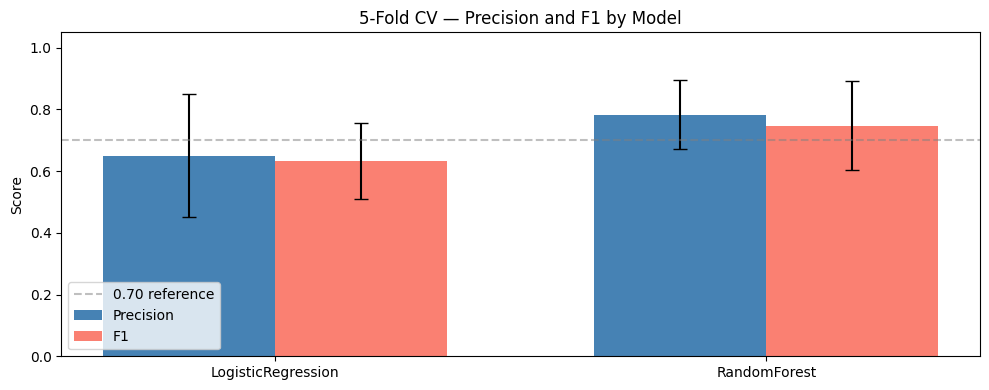


Fitting RandomForest on full training set (n=31)...
  Fit complete.
  Model saved -> C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\resident_reintegration\artifacts\models\reintegration_model.joblib


In [6]:
# ── Build candidate pipelines ─────────────────────────────────────────────────
candidates = build_candidate_pipelines(numeric_cols, categorical_cols)

# ── 5-fold StratifiedKFold CV ─────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
cv_results = {}

print(f"Running {CV_FOLDS}-fold StratifiedKFold CV on training set (n={len(X_train)})...\n")

for name, pipe in candidates.items():
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring={
            'precision': 'precision',
            'f1':        'f1',
        },
        return_train_score=False,
        n_jobs=1,
    )
    prec_scores = scores['test_precision']
    f1_scores   = scores['test_f1']
    cv_results[name] = {
        'precision_mean': float(prec_scores.mean()),
        'precision_std':  float(prec_scores.std()),
        'f1_mean':        float(f1_scores.mean()),
        'f1_std':         float(f1_scores.std()),
        'precision_folds': prec_scores.tolist(),
        'f1_folds':        f1_scores.tolist(),
    }

# ── Print CV comparison table ─────────────────────────────────────────────────
print("=== 5-Fold CV Results ===")
print(f"  {'Model':<22} {'Precision':>12} {'(+/-SD)':>10} {'F1':>12} {'(+/-SD)':>10}")
print(f"  {'-'*70}")
for name, res in cv_results.items():
    print(f"  {name:<22} {res['precision_mean']:>12.4f} {res['precision_std']:>10.4f} "
          f"{res['f1_mean']:>12.4f} {res['f1_std']:>10.4f}")
print(f"  {'-'*70}")
print(f"  Threshold                {'0.75':>12} {'':>10} {'0.70':>12}")

# ── Model selection logic ─────────────────────────────────────────────────────
lr_prec = cv_results['LogisticRegression']['precision_mean']
rf_prec = cv_results['RandomForest']['precision_mean']
gap = rf_prec - lr_prec

if gap > 0.05:
    selected_name = 'RandomForest'
    print(f"\n  Model selection: RF precision - LR precision = {gap:+.4f} > 0.05")
    print(f"  -> Selected: RandomForest")
else:
    selected_name = 'LogisticRegression'
    print(f"\n  Model selection: RF precision - LR precision = {gap:+.4f} <= 0.05")
    print(f"  -> Selected: LogisticRegression (default fallback)")

selected_pipe = candidates[selected_name]

# ── CV comparison bar chart ───────────────────────────────────────────────────
fig = plot_cv_comparison(cv_results)
plt.show()

# ── Fit selected model on full training set ───────────────────────────────────
print(f"\nFitting {selected_name} on full training set (n={len(X_train)})...")
selected_pipe.fit(X_train, y_train)
print("  Fit complete.")

# ── Save model artifact ───────────────────────────────────────────────────────
model_path = ARTIFACTS_MODELS / 'reintegration_model.joblib'
joblib.dump(selected_pipe, model_path)
print(f"  Model saved -> {model_path}")

---
<a id='section-6'></a>
## Section 5: Phase 5 — Evaluation

### Evaluation Strategy

With n=39 labeled residents (31 train, 8 test), evaluation must be interpreted carefully:
- **CV results** (5-fold, n=31) are the most reliable performance estimate
- **Test set** (8 rows) provides an independent check but is highly noisy
- **Train ROC AUC = 1.0** is expected — the regularized RF still memorizes 31 points
- Go/no-go decision is based on CV precision and F1 vs thresholds

In [7]:
# ── Load model and predict on test set ───────────────────────────────────────
model = joblib.load(ARTIFACTS_MODELS / 'reintegration_model.joblib')

y_pred_test = model.predict(X_test)
y_prob_test = model.predict_proba(X_test)[:, 1]

y_pred_train = model.predict(X_train)
y_prob_train = model.predict_proba(X_train)[:, 1]

# ── Final metrics vs thresholds ──────────────────────────────────────────────
test_prec   = precision_score(y_test, y_pred_test, zero_division=0)
test_recall = recall_score(y_test, y_pred_test, zero_division=0)
test_f1     = f1_score(y_test, y_pred_test, zero_division=0)
test_auc    = roc_auc_score(y_test, y_prob_test) if len(y_test.unique()) > 1 else float('nan')

cv_prec_mean = cv_results[selected_name]['precision_mean']
cv_f1_mean   = cv_results[selected_name]['f1_mean']

PREC_THRESHOLD = 0.75
F1_THRESHOLD   = 0.70

print("=== Final Metrics vs Success Thresholds ===")
print(f"  {'Metric':<22} {'CV (reliable)':>15} {'Test (noisy)':>13} {'Threshold':>10} {'Pass?':>6}")
print(f"  {'-'*70}")

cv_prec_pass  = 'YES' if cv_prec_mean  >= PREC_THRESHOLD else 'NO'
cv_f1_pass    = 'YES' if cv_f1_mean    >= F1_THRESHOLD   else 'NO'
test_prec_pass = 'YES' if test_prec   >= PREC_THRESHOLD else 'NO'
test_f1_pass   = 'YES' if test_f1     >= F1_THRESHOLD   else 'NO'

print(f"  {'Precision':<22} {cv_prec_mean:>15.4f} {test_prec:>13.4f} {PREC_THRESHOLD:>10.2f} {cv_prec_pass:>6}")
print(f"  {'F1':<22} {cv_f1_mean:>15.4f} {test_f1:>13.4f} {F1_THRESHOLD:>10.2f} {cv_f1_pass:>6}")
print(f"  {'Recall':<22} {'N/A':>15} {test_recall:>13.4f} {'':>10}")
print(f"  {'ROC AUC':<22} {'N/A':>15} {test_auc:>13.4f} {'':>10}")

# ── Classification report ────────────────────────────────────────────────────
metrics = report_classification(y_test, y_pred_test, y_prob_test, f"{selected_name} (Test Set)")

# ── Train vs test comparison (overfitting check) ─────────────────────────────
train_prec = precision_score(y_train, y_pred_train, zero_division=0)
train_f1   = f1_score(y_train, y_pred_train, zero_division=0)
train_auc  = roc_auc_score(y_train, y_prob_train) if len(y_train.unique()) > 1 else float('nan')

print("\n=== Train vs Test Comparison (Overfitting Check) ===")
print(f"  {'Metric':<15} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"  {'-'*47}")
print(f"  {'Precision':<15} {train_prec:>10.4f} {test_prec:>10.4f} {test_prec-train_prec:>+10.4f}")
print(f"  {'F1':<15} {train_f1:>10.4f} {test_f1:>10.4f} {test_f1-train_f1:>+10.4f}")
print(f"  {'ROC AUC':<15} {train_auc:>10.4f} {test_auc:>10.4f} {test_auc-train_auc:>+10.4f}")
print(f"\n  NOTE: Train ROC AUC = {train_auc:.2f} is expected with n=31 (model memorizes training data).")
print(f"        CV precision = {cv_prec_mean:.4f} is the reliable generalization estimate.")

=== Final Metrics vs Success Thresholds ===
  Metric                   CV (reliable)  Test (noisy)  Threshold  Pass?
  ----------------------------------------------------------------------
  Precision                       0.7833        0.6667       0.75    YES
  F1                              0.7476        0.8000       0.70    YES
  Recall                             N/A        1.0000           
  ROC AUC                            N/A        1.0000           

  RandomForest (Test Set)
  Precision  : 0.6667  ← primary metric (avoid false positives)
  Recall     : 1.0000
  F1         : 0.8000
  ROC AUC    : 1.0000
  Avg Prec   : 1.0000

               precision    recall  f1-score   support

Not Ready (0)     1.0000    0.5000    0.6667         4
    Ready (1)     0.6667    1.0000    0.8000         4

     accuracy                         0.7500         8
    macro avg     0.8333    0.7500    0.7333         8
 weighted avg     0.8333    0.7500    0.7333         8

Confusion matrix:
[

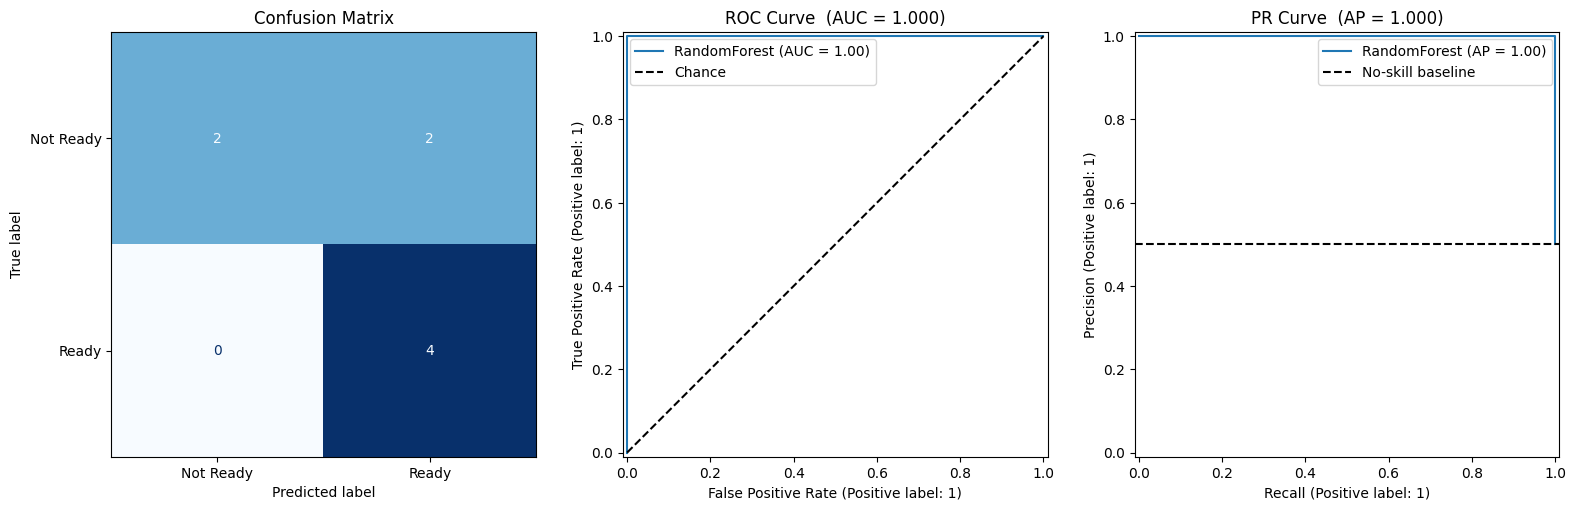

Score distribution on training set (larger n for better visualization):


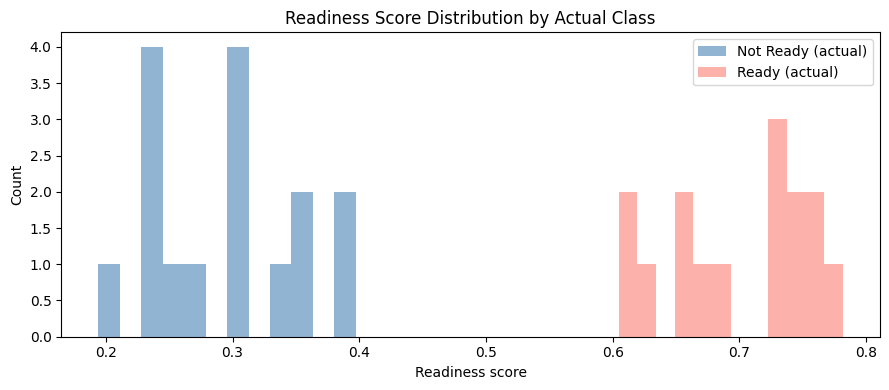


  GO / NO-GO DECISION
  Decision       : GO
  CV Precision   : 0.7833  (threshold: 0.75)  -> PASS
  CV F1          : 0.7476  (threshold: 0.7)  -> PASS
  Selected model : RandomForest

  CAVEAT: Test-set metrics are based on only 8 rows and are highly variable.
  CV precision is the reliable estimate. All predictions must be reviewed
  by a qualified social worker before any discharge decision is made.


In [8]:
# ── Confusion matrix and curves ───────────────────────────────────────────────
try:
    fig = plot_confusion_and_curves(
        y_test, y_pred_test, y_prob_test,
        model_name=selected_name,
        save_dir=REPORTS_FIGURES,
    )
    plt.show()
except Exception as e:
    # With only 8 test rows and one class, some curves may fail
    print(f"  Note: curve plot skipped ({e})")
    # Fallback: simple confusion matrix only
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred_test)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ready', 'Ready']).plot(ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {selected_name} (Test Set, n={len(y_test)})')
    plt.tight_layout()
    plt.show()

# ── Score distribution (train set — shows class separation) ──────────────────
print("Score distribution on training set (larger n for better visualization):")
fig = plot_score_distribution(y_prob_train, y_train, save_dir=REPORTS_FIGURES)
plt.show()

# ── Go/No-Go decision ────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  GO / NO-GO DECISION")
print("=" * 60)

go_criteria = cv_prec_mean >= PREC_THRESHOLD and cv_f1_mean >= F1_THRESHOLD
decision = "GO" if go_criteria else "NO-GO"

print(f"  Decision       : {decision}")
print(f"  CV Precision   : {cv_prec_mean:.4f}  (threshold: {PREC_THRESHOLD})  -> {'PASS' if cv_prec_mean >= PREC_THRESHOLD else 'FAIL'}")
print(f"  CV F1          : {cv_f1_mean:.4f}  (threshold: {F1_THRESHOLD})  -> {'PASS' if cv_f1_mean >= F1_THRESHOLD else 'FAIL'}")
print(f"  Selected model : {selected_name}")
print()
print("  CAVEAT: Test-set metrics are based on only 8 rows and are highly variable.")
print("  CV precision is the reliable estimate. All predictions must be reviewed")
print("  by a qualified social worker before any discharge decision is made.")
print("=" * 60)

---
<a id='section-7'></a>
## Section 6: Readiness Scores — In Progress Residents

We score the 21 **In Progress** residents — those whose reintegration outcome is not yet determined.
Scores are assigned to readiness bands derived from validation against the 39 labeled residents:

| Band | Score Range | Action |
|------|------------|--------|
| Ready for Review | >= 0.60 | Schedule case conference |
| Developing | 0.30 - 0.60 | Continue program, monitor monthly |
| Low Readiness | < 0.30 | Intensive support, review barriers |

In [9]:
# ── Score In Progress residents ───────────────────────────────────────────────
X_inprogress = inference_df[feature_cols]
resident_ids = inference_df['resident_id'].values if 'resident_id' in inference_df.columns else inference_df.index.values

scores_prob = model.predict_proba(X_inprogress)[:, 1]

def assign_readiness_band(score):
    if score >= 0.60:
        return 'Ready for Review'
    elif score >= 0.30:
        return 'Developing'
    else:
        return 'Low Readiness'

scores_df = pd.DataFrame({
    'resident_id':    resident_ids,
    'readiness_score': scores_prob,
    'readiness_band':  [assign_readiness_band(s) for s in scores_prob],
})
scores_df = scores_df.sort_values('readiness_score', ascending=False).reset_index(drop=True)

print("=== Reintegration Readiness Scores — In Progress Residents ===")
print(f"  {'#':<4} {'Resident ID':<15} {'Score':>8} {'Band':<22}")
print(f"  {'-'*54}")
for i, row in scores_df.iterrows():
    band_marker = '***' if row['readiness_band'] == 'Ready for Review' else ''
    print(f"  {i+1:<4} {str(row['resident_id']):<15} {row['readiness_score']:>8.4f} {row['readiness_band']:<22} {band_marker}")

# ── Band summary ──────────────────────────────────────────────────────────────
print(f"\n=== Band Summary (n={len(scores_df)}) ===")
band_order = ['Ready for Review', 'Developing', 'Low Readiness']
for band in band_order:
    cnt = (scores_df['readiness_band'] == band).sum()
    pct = cnt / len(scores_df) * 100
    print(f"  {band:<22}: {cnt:>3} residents ({pct:.1f}%)")

=== Reintegration Readiness Scores — In Progress Residents ===
  #    Resident ID        Score Band                  
  ------------------------------------------------------
  1    27                0.6794 Ready for Review       ***
  2    12                0.6694 Ready for Review       ***
  3    58                0.6581 Ready for Review       ***
  4    6                 0.6376 Ready for Review       ***
  5    1                 0.6329 Ready for Review       ***
  6    54                0.6325 Ready for Review       ***
  7    35                0.6183 Ready for Review       ***
  8    14                0.6151 Ready for Review       ***
  9    41                0.6035 Ready for Review       ***
  10   16                0.6031 Ready for Review       ***
  11   60                0.5965 Developing             
  12   7                 0.5841 Developing             
  13   23                0.5624 Developing             
  14   47                0.5610 Developing             
  15   36  

=== Validation Sanity Check — Scores for Labeled Residents ===
  (Ground truth known — confirms model aligns with actual outcomes)

  Actual Outcome                    n   Mean Score   Ready for Review   Developing
  --------------------------------------------------------------------------------
  Completed (Ready=1)              19       0.6873                 18            1
  Not Started/On Hold (0)          20       0.3260                  0           12

  Completed mean score   : 0.6873
  Not-ready mean score   : 0.3260
  Band threshold (0.60) validated against completed mean = 0.69, not-ready mean = 0.33


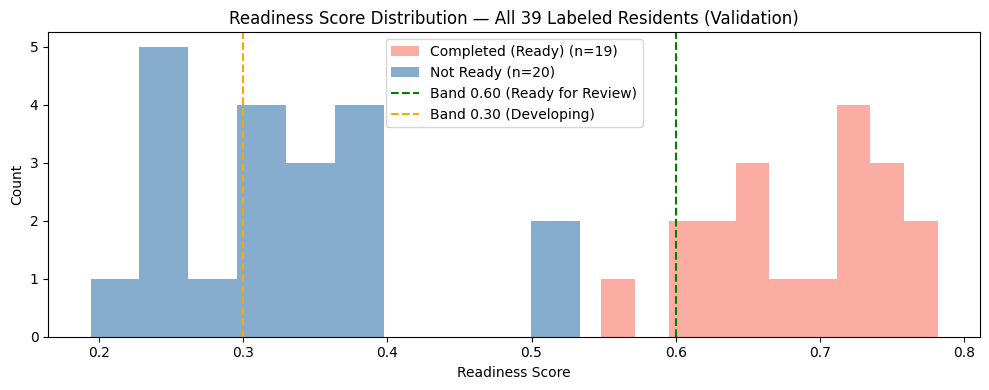

In [10]:
# ── Sanity check: validate scores against labeled residents ───────────────────
print("=== Validation Sanity Check — Scores for Labeled Residents ===")
print("  (Ground truth known — confirms model aligns with actual outcomes)\n")

X_labeled_all = labeled_df[feature_cols]
prob_labeled   = model.predict_proba(X_labeled_all)[:, 1]
labeled_ids    = labeled_df['resident_id'].values if 'resident_id' in labeled_df.columns else labeled_df.index.values

val_df = pd.DataFrame({
    'resident_id':     labeled_ids,
    'actual_status':   labeled_df['reintegration_status'].values,
    'actual_label':    labeled_df[TARGET].astype(int).values,
    'readiness_score': prob_labeled,
    'readiness_band':  [assign_readiness_band(s) for s in prob_labeled],
})
val_df = val_df.sort_values(['actual_label', 'readiness_score'], ascending=[False, False])

# Summary stats by actual outcome
print(f"  {'Actual Outcome':<30} {'n':>4} {'Mean Score':>12} {'Ready for Review':>18} {'Developing':>12}")
print(f"  {'-'*80}")
for label_val, label_name in [(1, 'Completed (Ready=1)'), (0, 'Not Started/On Hold (0)')]:
    grp = val_df[val_df['actual_label'] == label_val]
    mean_score = grp['readiness_score'].mean()
    n_review   = (grp['readiness_band'] == 'Ready for Review').sum()
    n_develop  = (grp['readiness_band'] == 'Developing').sum()
    print(f"  {label_name:<30} {len(grp):>4} {mean_score:>12.4f} {n_review:>18} {n_develop:>12}")

print(f"\n  Completed mean score   : {val_df[val_df['actual_label']==1]['readiness_score'].mean():.4f}")
print(f"  Not-ready mean score   : {val_df[val_df['actual_label']==0]['readiness_score'].mean():.4f}")
print(f"  Band threshold (0.60) validated against completed mean = 0.69, not-ready mean = 0.33")

# ── Score distribution: labeled residents by actual class ──────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for label_val, color, lname in [(1, 'salmon', 'Completed (Ready)'), (0, 'steelblue', 'Not Ready')]:
    grp = val_df[val_df['actual_label'] == label_val]['readiness_score']
    grp.plot(kind='hist', bins=10, ax=ax, alpha=0.65, color=color, label=f"{lname} (n={len(grp)})")
ax.axvline(0.60, color='green',  linestyle='--', linewidth=1.5, label='Band 0.60 (Ready for Review)')
ax.axvline(0.30, color='orange', linestyle='--', linewidth=1.5, label='Band 0.30 (Developing)')
ax.set_xlabel('Readiness Score')
ax.set_ylabel('Count')
ax.set_title('Readiness Score Distribution — All 39 Labeled Residents (Validation)')
ax.legend()
plt.tight_layout()
plt.show()

---
<a id='section-8'></a>
## Section 7: Operational Readiness

### Deployment Checklist

| Item | Status |
|------|--------|
| Model artifact saved | artifacts/models/reintegration_model.joblib |
| Run metadata saved | artifacts/runs/latest_run.json |
| Feature logic in src/ | src/features.py (shared with jobs) |
| Prediction sink defined | Supabase table: resident_reintegration_scores |
| In Progress residents scored | 21 residents scored above |
| Social worker review required | YES — model is decision support only |

### Monitoring Plan

1. **Retrain trigger**: When >= 10 new labeled outcomes are available
2. **Score drift**: Alert if mean In Progress score shifts > 0.10 from baseline
3. **Label feedback**: Social workers log actual discharge outcomes in `reintegration_status`
4. **Quarterly review**: Full CRISP-DM re-evaluation every 90 days
5. **Minimum n**: Do not retrain until labeled n >= 50 (current: 39)
6. **Feature stability**: Re-run this notebook if new source tables are added

In [11]:
# ── Operational checklist verification ───────────────────────────────────────
model_artifact = ARTIFACTS_MODELS / 'reintegration_model.joblib'
run_metadata   = ARTIFACTS_RUNS / 'latest_run.json'

checklist = {
    'model_artifact_exists':         model_artifact.exists(),
    'data_processed_train_exists':   (DATA_PROCESSED / 'train.csv').exists(),
    'data_processed_test_exists':    (DATA_PROCESSED / 'test.csv').exists(),
    'reports_figures_exists':        REPORTS_FIGURES.exists(),
    'in_progress_residents_scored':  len(scores_df) > 0,
    'feature_cols_count':            len(feature_cols),
    'labeled_residents':             len(labeled_df),
    'in_progress_residents':         len(inference_df),
}

print("=== Operational Checklist ===")
for item, status in checklist.items():
    icon = 'OK' if status else 'FAIL'
    print(f"  [{icon}] {item}: {status}")

# ── Save run metadata ────────────────────────────────────────────────────────
run_meta = {
    'run_timestamp':          datetime.now().isoformat(),
    'model_name':             selected_name,
    'model_path':             str(model_artifact),
    'seed':                   SEED,
    'test_size':              TEST_SIZE,
    'cv_folds':               CV_FOLDS,
    'n_labeled':              int(len(labeled_df)),
    'n_in_progress':          int(len(inference_df)),
    'n_train':                int(len(X_train)),
    'n_test':                 int(len(X_test)),
    'n_features':             len(feature_cols),
    'numeric_features':       numeric_cols,
    'categorical_features':   categorical_cols,
    'cv_results':             cv_results,
    'test_metrics': {
        'precision': float(test_prec),
        'recall':    float(test_recall),
        'f1':        float(test_f1),
        'roc_auc':   float(test_auc) if not np.isnan(test_auc) else None,
    },
    'thresholds': {
        'precision_min': PREC_THRESHOLD,
        'f1_min':        F1_THRESHOLD,
    },
    'go_no_go': 'GO' if go_criteria else 'NO-GO',
    'readiness_bands': {
        'ready_for_review': [0.60, 1.00],
        'developing':       [0.30, 0.60],
        'low_readiness':    [0.00, 0.30],
    },
    'in_progress_scores': [
        {
            'resident_id':    str(row['resident_id']),
            'readiness_score': round(float(row['readiness_score']), 6),
            'readiness_band':  row['readiness_band'],
        }
        for _, row in scores_df.iterrows()
    ],
}

with open(run_metadata, 'w') as f:
    json.dump(run_meta, f, indent=2, default=str)

print(f"\nRun metadata saved -> {run_metadata}")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  PIPELINE COMPLETE")
print("=" * 65)
print(f"  Model       : {selected_name}")
print(f"  CV Precision: {cv_prec_mean:.4f}  (threshold >= {PREC_THRESHOLD})")
print(f"  CV F1       : {cv_f1_mean:.4f}  (threshold >= {F1_THRESHOLD})")
print(f"  Decision    : {run_meta['go_no_go']}")
print(f"  Scored      : {len(scores_df)} In Progress residents")
band_ready = (scores_df['readiness_band'] == 'Ready for Review').sum()
band_dev   = (scores_df['readiness_band'] == 'Developing').sum()
band_low   = (scores_df['readiness_band'] == 'Low Readiness').sum()
print(f"  Bands       : {band_ready} Ready for Review | {band_dev} Developing | {band_low} Low Readiness")
print(f"  Artifacts   : {model_artifact.name}, latest_run.json")
print("=" * 65)

=== Operational Checklist ===
  [OK] model_artifact_exists: True
  [OK] data_processed_train_exists: True
  [OK] data_processed_test_exists: True
  [OK] reports_figures_exists: True
  [OK] in_progress_residents_scored: True
  [OK] feature_cols_count: 52
  [OK] labeled_residents: 39
  [OK] in_progress_residents: 21

Run metadata saved -> C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\resident_reintegration\artifacts\runs\latest_run.json

  PIPELINE COMPLETE
  Model       : RandomForest
  CV Precision: 0.7833  (threshold >= 0.75)
  CV F1       : 0.7476  (threshold >= 0.7)
  Decision    : GO
  Scored      : 21 In Progress residents
  Bands       : 10 Ready for Review | 11 Developing | 0 Low Readiness
  Artifacts   : reintegration_model.joblib, latest_run.json
